# Linear Algebra Review

> Based on *Linear Algebra Review and Reference* — Zico Kolter

Linear algebra provides a way of compactly representing and operating on sets of linear equations.

$$Ax = b \qquad A \in \mathbb{R}^{m \times n},\; x \in \mathbb{R}^n,\; b \in \mathbb{R}^m$$

## Quick overview — what is linear algebra *for*?

Linear algebra is the **language of data and transformations**:

- A **vector** is a point / direction in space (a row of data, a gradient, an embedding).
- A **matrix** is a *function* that maps vectors to vectors — it can **rotate, scale, project, shear**.
- Almost every ML model can be written as: `output = f(W · x + b)` — a matrix-vector product plus a non-linearity.

The picture below shows the two core ideas: vectors as arrows, and a matrix `A` reshaping the unit square.


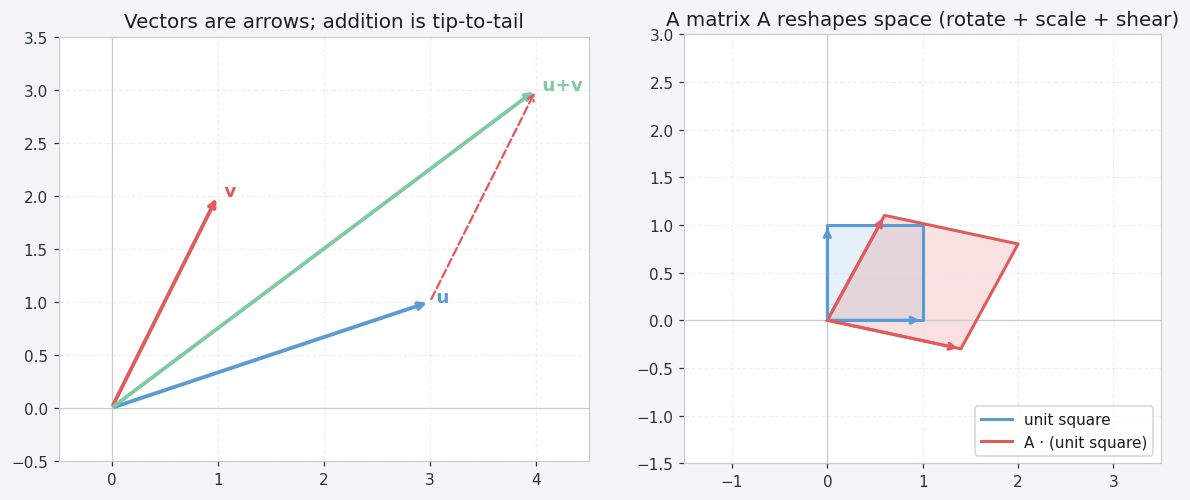

In [1]:
# (quick-overview schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':13,'axes.labelsize':11,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

# --- left: vectors as arrows ---
ax = axes[0]
ax.set_title('Vectors are arrows; addition is tip-to-tail')
ax.set_xlim(-0.5, 4.5); ax.set_ylim(-0.5, 3.5); ax.set_aspect('equal')
ax.axhline(0, color='#c8ccd4', lw=0.8); ax.axvline(0, color='#c8ccd4', lw=0.8)
ax.grid(True)
u = np.array([3, 1]); v = np.array([1, 2])
ax.annotate('', xy=u,     xytext=(0,0), arrowprops=dict(arrowstyle='->', color=P[0], lw=2.5))
ax.annotate('', xy=v,     xytext=(0,0), arrowprops=dict(arrowstyle='->', color=P[1], lw=2.5))
ax.annotate('', xy=u+v,   xytext=(0,0), arrowprops=dict(arrowstyle='->', color=P[3], lw=2.5))
ax.annotate('', xy=u+v,   xytext=u,     arrowprops=dict(arrowstyle='->', color=P[1], lw=1.5, ls='--'))
ax.text(*u,   ' u', color=P[0], fontsize=12, weight='bold')
ax.text(*v,   ' v', color=P[1], fontsize=12, weight='bold')
ax.text(*(u+v), ' u+v', color=P[3], fontsize=12, weight='bold')

# --- right: matrix transforms the unit square ---
ax = axes[1]
ax.set_title('A matrix A reshapes space (rotate + scale + shear)')
ax.set_xlim(-1.5, 3.5); ax.set_ylim(-1.5, 3.0); ax.set_aspect('equal')
ax.axhline(0, color='#c8ccd4', lw=0.8); ax.axvline(0, color='#c8ccd4', lw=0.8)
ax.grid(True)
square = np.array([[0,0],[1,0],[1,1],[0,1],[0,0]]).T
A = np.array([[1.4, 0.6],[ -0.3, 1.1]])
transformed = A @ square
ax.plot(square[0],      square[1],      color=P[0], lw=2, label='unit square')
ax.fill(square[0],      square[1],      color=P[0], alpha=0.15)
ax.plot(transformed[0], transformed[1], color=P[1], lw=2, label='A · (unit square)')
ax.fill(transformed[0], transformed[1], color=P[1], alpha=0.18)
# basis vectors
ax.annotate('', xy=(1,0), xytext=(0,0), arrowprops=dict(arrowstyle='->', color=P[0], lw=2))
ax.annotate('', xy=(0,1), xytext=(0,0), arrowprops=dict(arrowstyle='->', color=P[0], lw=2))
ax.annotate('', xy=A[:,0], xytext=(0,0), arrowprops=dict(arrowstyle='->', color=P[1], lw=2))
ax.annotate('', xy=A[:,1], xytext=(0,0), arrowprops=dict(arrowstyle='->', color=P[1], lw=2))
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()


## Learning Objectives

By the end of this notebook, you will be able to:

1. **Represent** vectors, matrices, and linear systems in compact notation and translate between equation, vector, and matrix forms
2. **Apply** matrix operations (multiplication, transpose, inverse) and explain their geometric meaning
3. **Compute** gradients of scalar functions with respect to vectors and matrices using key identities ($\nabla_x b^Tx = b$, $\nabla_x x^TAx = 2Ax$)
4. **Decompose** symmetric matrices via eigendecomposition and interpret eigenvalues geometrically
5. **Identify** positive definite matrices and explain why they guarantee convex optimization
6. **Derive** the Normal Equation $(X^TX)^{-1}X^Ty$ for least squares using matrix calculus

> **Prerequisite**: Basic calculus (derivatives, chain rule).

> **How to use**: Read each section's explanation first, then run the code to verify the math. At each visualization, ask: *"What does this picture tell me that the equation doesn't?"*

In [2]:
import numpy as np

## 1. Basic Notation

| Symbol | Meaning |
|---|---|
| $A \in \mathbb{R}^{m \times n}$ | Matrix with $m$ rows, $n$ columns |
| $x \in \mathbb{R}^n$ | Column vector ($n \times 1$ matrix) |
| $x^T$ | Row vector (transpose of $x$) |
| $A_{ij}$ or $a_{ij}$ | Entry at row $i$, column $j$ |
| $a_j$ or $A_{:,j}$ | $j$-th column of $A$ |
| $a_i^T$ or $A_{i,:}$ | $i$-th row of $A$ |

**Example** — $A \in \mathbb{R}^{2 \times 3}$ with entries labeled:

$$A = \begin{bmatrix} 1 & \mathbf{2} & 3 \\ 4 & 5 & 6 \end{bmatrix}$$

- $A_{12} = 2$ — row 1, column 2
- $a_3 = \begin{bmatrix}3\\6\end{bmatrix}$ — 3rd column, a $2$-vector
- $a_2^T = \begin{bmatrix}4 & 5 & 6\end{bmatrix}$ — 2nd row, a $3$-vector

For $x = \begin{bmatrix}1\\2\\3\end{bmatrix} \in \mathbb{R}^3$, the transpose flips it to a row: $x^T = \begin{bmatrix}1 & 2 & 3\end{bmatrix}$.

In [3]:
A = np.array([[1, 2, 3],
              # A ∈ R^{2×3}
              [4, 5, 6]])
# x ∈ R^3 (column vector)
x = np.array([[1], [2], [3]])

print("A =\n", A)
print("shape:", A.shape)
# a_12
print("A[0,1] =", A[0, 1])
# a_2 (2nd column)
print("col 1:", A[:, 1])
# a_1^T (1st row)
print("row 0:", A[0, :])
print("x =\n", x)


A =
 [[1 2 3]
 [4 5 6]]
shape: (2, 3)
A[0,1] = 2
col 1: [2 5]
row 0: [1 2 3]
x =
 [[1]
 [2]
 [3]]


## 2. Matrix Multiplication

For $A \in \mathbb{R}^{m \times n}$ and $B \in \mathbb{R}^{n \times p}$, their product $C = AB \in \mathbb{R}^{m \times p}$ where:
$$C_{ij} = \sum_{k=1}^{n} A_{ik} B_{kj}$$

### 2.1 Vector–Vector Products

**Inner product (dot product)** — $x, y \in \mathbb{R}^n$, result is a scalar:
$$x^T y = \sum_{i=1}^{n} x_i y_i \in \mathbb{R}$$

**Example:**

$$\begin{bmatrix}1 & 2 & 3\end{bmatrix}\begin{bmatrix}4\\5\\6\end{bmatrix} = 1\cdot4 + 2\cdot5 + 3\cdot6 = 4+10+18 = 32$$

Geometric meaning: $x^Ty = \|x\|_2\|y\|_2\cos\theta$ — large when $x,y$ point the same way; zero when perpendicular.

**Outer product** — $x \in \mathbb{R}^m$, $y \in \mathbb{R}^n$, result is a matrix:
$$xy^T \in \mathbb{R}^{m \times n}, \quad (xy^T)_{ij} = x_i y_j$$

**Example:** every row is a scalar multiple of $y^T$, so $\text{rank}(xy^T) = 1$:

$$\begin{bmatrix}1\\2\end{bmatrix}\begin{bmatrix}3 & 4 & 5\end{bmatrix} = \begin{bmatrix}1\cdot3 & 1\cdot4 & 1\cdot5\\ 2\cdot3 & 2\cdot4 & 2\cdot5\end{bmatrix} = \begin{bmatrix}3 & 4 & 5\\ 6 & 8 & 10\end{bmatrix}$$

### 2.2 Matrix–Vector Product

$y = Ax \in \mathbb{R}^m$ can be viewed as:
- A collection of inner products: $y_i = a_i^T x$ (row view)
- A linear combination of columns of $A$: $y = \sum_j x_j a_j$ (column view)

**Example** — column view shows $Ax$ as a weighted sum of columns:

$$\begin{bmatrix}1 & 2\\ 3 & 4\\ 5 & 6\end{bmatrix}\begin{bmatrix}1\\2\end{bmatrix} = 1\cdot\underbrace{\begin{bmatrix}1\\3\\5\end{bmatrix}}_{\text{col 1}} + 2\cdot\underbrace{\begin{bmatrix}2\\4\\6\end{bmatrix}}_{\text{col 2}} = \begin{bmatrix}5\\11\\17\end{bmatrix}$$

This is what "linear" means: the output is a linear combination of the columns.

Similarly, $y^T = x^T A$ for $x \in \mathbb{R}^m$ gives a row vector where:
- $y_i = x^T a_i$ (inner product of $x$ with $i$-th column)

### 2.3 Matrix–Matrix Product

$C = AB$ has four equivalent interpretations:

| Viewpoint | Formula | Intuition |
|---|---|---|
| Entry as inner product | $C_{ij} = a_i^T b_j$ | Row $i$ of $A$ dotted with col $j$ of $B$ |
| Sum of outer products | $C = \sum_{k=1}^n a_k b_k^T$ | $k$-th col of $A$ × $k$-th row of $B$ |
| Column view | $c_j = A b_j$ | Each col of $C$ = $A$ times col of $B$ |
| Row view | $c_i^T = a_i^T B$ | Each row of $C$ = row of $A$ times $B$ |

**Example** — computing entry $C_{12}$ via row-dot-column:

$$C = \begin{bmatrix}1 & 2\\ 3 & 4\end{bmatrix}\begin{bmatrix}5 & 6\\ 7 & 8\end{bmatrix}, \qquad C_{12} = \underbrace{\begin{bmatrix}1 & 2\end{bmatrix}}_{\text{row 1 of }A}\underbrace{\begin{bmatrix}6\\8\end{bmatrix}}_{\text{col 2 of }B} = 6 + 16 = 22$$

Key properties:
- **Associative:** $(AB)C = A(BC)$
- **Distributive:** $A(B+C) = AB + AC$
- **Not commutative:** $AB \neq BA$ in general

In [4]:
x = np.array([1, 2, 3])
y = np.array([4, 5, 6])

# Inner product (dot product)
# 1*4 + 2*5 + 3*6 = 32
print("Inner product x·y =", x @ y)

# Outer product
print("Outer product xy^T =\n", np.outer(x, y))

# Matrix-vector product
# 3×2
A = np.array([[1, 2], [3, 4], [5, 6]])
v = np.array([1, 2])
print("Av =", A @ v)

# Row view: y_i = a_i^T x
print("Row view:", [A[i] @ v for i in range(3)])

# Column view: linear combination of columns
print("Column view:", v[0]*A[:,0] + v[1]*A[:,1])

# Matrix-matrix product
B = np.array([[1, 2], [3, 4]])
C = np.array([[5, 6], [7, 8]])
print("BC =\n", B @ C)
print("CB =\n", C @ B)
print("BC == CB?", np.allclose(B @ C, C @ B))


Inner product x·y = 32
Outer product xy^T =
 [[ 4  5  6]
 [ 8 10 12]
 [12 15 18]]
Av = [ 5 11 17]
Row view: [np.int64(5), np.int64(11), np.int64(17)]
Column view: [ 5 11 17]
BC =
 [[19 22]
 [43 50]]
CB =
 [[23 34]
 [31 46]]
BC == CB? False


## 3. Operations and Properties

### 3.1 Identity and Diagonal Matrices

**Identity matrix** $I \in \mathbb{R}^{n \times n}$: $I_{ij} = \mathbf{1}[i = j]$. For all $A$: $AI = IA = A$.

**Example** — identity leaves any vector unchanged:

$$\begin{bmatrix}1 & 0 \\ 0 & 1\end{bmatrix}\begin{bmatrix}3\\5\end{bmatrix} = \begin{bmatrix}3\\5\end{bmatrix}$$

**Diagonal matrix** $D = \text{diag}(d_1, \ldots, d_n)$: non-zero entries only on main diagonal.

**Example** — diagonal matrix scales each component independently:

$$\begin{bmatrix}2 & 0 \\ 0 & 3\end{bmatrix}\begin{bmatrix}x_1\\x_2\end{bmatrix} = \begin{bmatrix}2x_1\\3x_2\end{bmatrix} \quad \leftarrow \text{stretches axis 1 by 2, axis 2 by 3}$$

### 3.2 Transpose

$(A^T)_{ij} = A_{ji}$ — reflect entries across the main diagonal.

**Example:**

$$A = \begin{bmatrix}1 & 2 & 3 \\ 4 & 5 & 6\end{bmatrix} \xrightarrow{\text{transpose}} A^T = \begin{bmatrix}1 & 4 \\ 2 & 5 \\ 3 & 6\end{bmatrix}$$

Properties:
- $(A^T)^T = A$
- $(AB)^T = B^T A^T$ — order reverses (put on gloves then shoes → remove shoes first)
- $(A + B)^T = A^T + B^T$

### 3.3 Symmetric Matrices

$A \in \mathbb{R}^{n \times n}$ is **symmetric** if $A = A^T$; **anti-symmetric** if $A = -A^T$.

**Example** — $A_{12} = A_{21}$, mirror symmetry about the diagonal:

$$A = \begin{bmatrix}1 & \mathbf{2} \\ \mathbf{2} & 3\end{bmatrix} = A^T$$

Any square matrix $A$ can be decomposed: $A = \frac{1}{2}(A + A^T) + \frac{1}{2}(A - A^T)$

The set of all symmetric $n \times n$ matrices is denoted $\mathbb{S}^n$.

In [5]:
n = 3
print("Identity:\n", np.eye(n))
print("Diagonal(1,2,3):\n", np.diag([1, 2, 3]))

A = np.array([[1, 2, 3], [4, 5, 6]])
print("A^T =\n", A.T)
print("(A^T)^T == A:", np.allclose(A.T.T, A))

B = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
C = np.array([[9, 8, 7], [6, 5, 4], [3, 2, 1]])
print("(BC)^T == C^T B^T:", np.allclose((B @ C).T, C.T @ B.T))

# Symmetric / anti-symmetric decomposition
M = np.array([[1., 2., 4.], [3., 5., 7.], [6., 8., 9.]])
sym   = (M + M.T) / 2
anti  = (M - M.T) / 2
print("sym + anti == M:", np.allclose(sym + anti, M))
print("sym == sym^T:", np.allclose(sym, sym.T))
print("anti == -anti^T:", np.allclose(anti, -anti.T))

Identity:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
Diagonal(1,2,3):
 [[1 0 0]
 [0 2 0]
 [0 0 3]]
A^T =
 [[1 4]
 [2 5]
 [3 6]]
(A^T)^T == A: True
(BC)^T == C^T B^T: True
sym + anti == M: True
sym == sym^T: True
anti == -anti^T: True


### 3.4 Trace

For $A \in \mathbb{R}^{n \times n}$:

$$\text{tr}A = \sum_{i=1}^{n} A_{ii}$$

**Example** — only the main diagonal (bold) contributes:

$$\text{tr}\begin{bmatrix}\mathbf{1} & 2 & 3 \\ 4 & \mathbf{5} & 6 \\ 7 & 8 & \mathbf{9}\end{bmatrix} = 1 + 5 + 9 = 15$$

Properties:
- $\text{tr}A = \text{tr}A^T$
- $\text{tr}(A + B) = \text{tr}A + \text{tr}B$
- $\text{tr}(tA) = t\,\text{tr}A$
- **Cyclic property:** $\text{tr}(ABC) = \text{tr}(CAB) = \text{tr}(BCA)$
- $\text{tr}(AB) = \text{tr}(BA)$ even when $AB \neq BA$

In [6]:
A = np.array([[1., 2.], [3., 4.]])
B = np.array([[5., 6.], [7., 8.]])

# 1 + 4 = 5
print("tr(A)  =", np.trace(A))
print("tr(AB) =", np.trace(A @ B))
# cyclic: tr(AB) == tr(BA)
print("tr(BA) =", np.trace(B @ A))


tr(A)  = 5.0
tr(AB) = 69.0
tr(BA) = 69.0


### 3.5 Norms

A norm $\|x\|$ must satisfy:
1. $\|x\| \geq 0$; $\|x\| = 0 \Leftrightarrow x = 0$
2. $\|tx\| = |t|\|x\|$
3. $\|x + y\| \leq \|x\| + \|y\|$ (triangle inequality)

**Vector norms:**

$$\ell_p: \|x\|_p = \left(\sum_i |x_i|^p\right)^{1/p}$$

> **Note:** $\ell_0$ is not a true norm — it fails homogeneity ($\|tx\|_0 \neq |t|\|x\|_0$ for $t \neq 0, 1$). It is used as a sparsity measure in compressed sensing and sparse learning.

**Example** — $x = [1,\ 0,\ -2,\ 0,\ 3]$:

| Norm | Formula | Computation | Value | Measures |
|---|---|---|---|---|
| $\ell_0$ | $\#\{i : x_i \neq 0\}$ | entries $1, -2, 3$ are non-zero | $3$ | sparsity (count) |
| $\ell_1$ | $\sum_i \lvert x_i \rvert$ | $1 + 0 + 2 + 0 + 3$ | $6$ | taxicab distance |
| $\ell_2$ | $\sqrt{\sum_i x_i^2}$ | $\sqrt{1 + 0 + 4 + 0 + 9}$ | $\approx 3.74$ | straight-line length |
| $\ell_\infty$ | $\max_i \lvert x_i \rvert$ | $\max(1, 0, 2, 0, 3)$ | $3$ | worst-case / largest entry |

**Matrix norm (Frobenius):**
$$\|A\|_F = \sqrt{\sum_{i,j} A_{ij}^2} = \sqrt{\text{tr}(A^T A)}$$

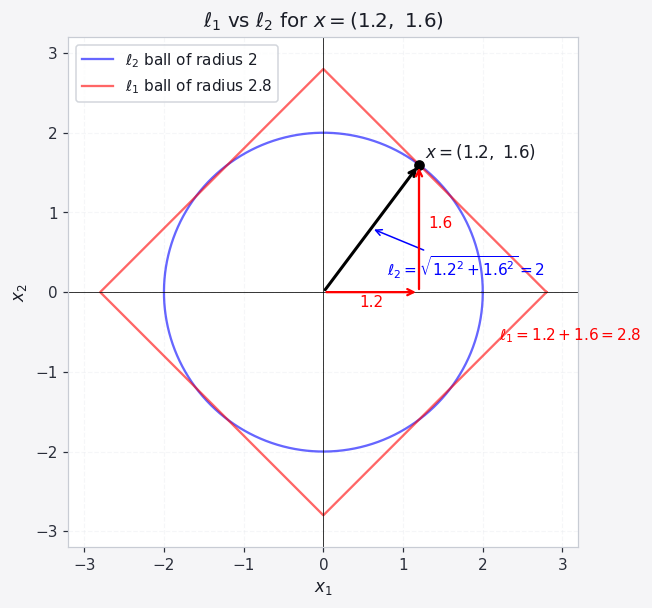

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# vector with L2 norm exactly 2
x = np.array([1.2, 1.6])   # L2 = sqrt(1.44 + 2.56) = 2,  L1 = 1.2 + 1.6 = 2.8

fig, ax = plt.subplots(figsize=(6, 6))
theta = np.linspace(0, 2 * np.pi, 500)

# L2 circle passing through x (radius = 2)
ax.plot(2 * np.cos(theta), 2 * np.sin(theta), 'b-', lw=1.5, alpha=0.6,
        label=r'$\ell_2$ ball of radius 2')

# L1 diamond passing through x (radius = 2.8)
r1 = 1.2 + 1.6
dx = [r1, 0, -r1, 0, r1]
dy = [0, r1, 0, -r1, 0]
ax.plot(dx, dy, 'r-', lw=1.5, alpha=0.6, label=r'$\ell_1$ ball of radius 2.8')

# the vector
ax.annotate('', xy=x, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='k', lw=2))
ax.plot(*x, 'ko', ms=6)
ax.text(x[0] + 0.08, x[1] + 0.08, r'$x = (1.2,\ 1.6)$', fontsize=11)

# L2 path: straight line (already the arrow above)
ax.annotate(r'$\ell_2 = \sqrt{1.2^2+1.6^2} = 2$', xy=x/2, xytext=(0.8, 0.2),
            arrowprops=dict(arrowstyle='->', color='blue'), color='blue', fontsize=10)

# L1 path: Manhattan (go right then up)
ax.annotate('', xy=(x[0], 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5,
                            connectionstyle='arc3,rad=0'))
ax.annotate('', xy=(x[0], x[1]), xytext=(x[0], 0),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
ax.text(x[0]/2, -0.18, '1.2', ha='center', color='red', fontsize=10)
ax.text(x[0] + 0.12, x[1]/2, '1.6', ha='left', color='red', fontsize=10)
ax.text(2.2, -0.6, r'$\ell_1 = 1.2 + 1.6 = 2.8$', color='red', fontsize=10)

ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
ax.set_xlim(-3.2, 3.2)
ax.set_ylim(-3.2, 3.2)
ax.set_aspect('equal')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title(r'$\ell_1$ vs $\ell_2$ for $x = (1.2,\ 1.6)$', fontsize=13)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Why is a circle and diamond plotted?**

The circle and diamond are **equinorm contours** — the set of all 2D vectors that have the exact same norm as $x$:

- **Blue circle** — every point on it has $\ell_2 = 2$. It is a circle because $\ell_2$ treats all directions equally (rotation-invariant).
- **Red diamond** — every point on it has $\ell_1 = 2.8$. It is a diamond because $\ell_1$ only cares about axis-aligned distances, so it is not rotation-invariant.

**Why this matters for regularization:** when you add an $\ell_1$ or $\ell_2$ penalty to a loss function, you are constraining $x$ to lie inside one of these shapes. The loss contours expand outward until they first touch the constraint boundary. Because the $\ell_1$ diamond has **corners on the axes**, it tends to be touched at a sparse point like $(2.8,\ 0)$ rather than a mixed point like $(1.2,\ 1.6)$ — this is why $\ell_1$ regularization (Lasso) produces sparse solutions.

In [8]:
x = np.array([1., -2., 3.])
A = np.array([[1., 2.], [3., 4.]])

# 2 (non-zero entries: all three are non-zero, but let's use a mixed example)
x_sparse = np.array([1., 0., -2., 0., 3.])
# number of non-zeros (not a true norm)
print("ℓ0:", np.count_nonzero(x_sparse))
# 6.0
print("ℓ1:", np.linalg.norm(x, ord=1))
# sqrt(14)
print("ℓ2:", np.linalg.norm(x))
# 3.0
print("ℓ∞:", np.linalg.norm(x, ord=np.inf))

frob_direct = np.linalg.norm(A, 'fro')
frob_trace  = np.sqrt(np.trace(A.T @ A))
print(f"Frobenius: {frob_direct:.4f}, via trace: {frob_trace:.4f}")

ℓ0: 3
ℓ1: 6.0
ℓ2: 3.7416573867739413
ℓ∞: 3.0
Frobenius: 5.4772, via trace: 5.4772


### 3.6 Linear Independence and Rank

A set of vectors $\{v_1, \ldots, v_k\}$ is **linearly independent** if no vector can be expressed as a linear combination of the others.

**Example — independent vs. dependent:**

$$\text{Independent: } v_1 = \begin{bmatrix}1\\0\end{bmatrix},\ v_2 = \begin{bmatrix}0\\1\end{bmatrix} \qquad \text{no scalar }c\text{ satisfies }v_1 = c\,v_2$$

$$\text{Dependent: } v_1 = \begin{bmatrix}1\\2\end{bmatrix},\ v_2 = \begin{bmatrix}2\\4\end{bmatrix} \qquad v_2 = 2v_1 \text{ — same direction, no new information}$$

Independent vectors point in genuinely different directions and span more space. Dependent vectors "pile on top of each other."

**Column rank** = dimension of the column space = max number of linearly independent columns.
**Row rank** = dimension of the row space.
For any matrix, column rank = row rank — simply called the **rank**.

**Example:**

$$A = \begin{bmatrix}1 & 2 & 3 \\ 2 & 4 & 6\end{bmatrix} \quad \leftarrow \text{row 2} = 2\times\text{row 1},\; \text{rank} = 1$$

$$B = \begin{bmatrix}1 & 0 \\ 0 & 1 \\ 1 & 1\end{bmatrix} \quad \leftarrow \text{columns are independent},\; \text{rank} = 2$$

Properties:
- $\text{rank}(A) \leq \min(m, n)$
- $A \in \mathbb{R}^{m \times n}$ with $\text{rank}(A) = \min(m,n)$ is **full rank**
- $\text{rank}(A) = \text{rank}(A^T)$
- $\text{rank}(AB) \leq \min(\text{rank}(A), \text{rank}(B))$
- $\text{rank}(A + B) \leq \text{rank}(A) + \text{rank}(B)$

In [9]:
full_rank = np.array([[1., 2., 3.],
                      [4., 5., 6.],
                      # linearly independent rows
                      [7., 8., 10.]])

rank_def  = np.array([[1., 2., 3.],
                      # = 2 × row 0
                      [2., 4., 6.],
                      [1., 1., 1.]])

# 3
print("full_rank rank:", np.linalg.matrix_rank(full_rank))
# 2
print("rank_def  rank:", np.linalg.matrix_rank(rank_def))


full_rank rank: 3
rank_def  rank: 2


### 3.7 The Inverse

For $A \in \mathbb{R}^{n \times n}$, the **inverse** $A^{-1}$ satisfies $A^{-1}A = I = AA^{-1}$.

$A^{-1}$ exists if and only if $A$ is **full rank** (non-singular).

**Example** — $2\times2$ inverse formula $A^{-1} = \frac{1}{ad-bc}\begin{bmatrix}d & -b \\ -c & a\end{bmatrix}$:

$$A = \begin{bmatrix}2 & 1 \\ 1 & 1\end{bmatrix}, \quad A^{-1} = \frac{1}{2-1}\begin{bmatrix}1 & -1 \\ -1 & 2\end{bmatrix} = \begin{bmatrix}1 & -1 \\ -1 & 2\end{bmatrix}$$

Verify: $A^{-1}A = \begin{bmatrix}1 & -1 \\ -1 & 2\end{bmatrix}\begin{bmatrix}2 & 1 \\ 1 & 1\end{bmatrix} = \begin{bmatrix}1 & 0 \\ 0 & 1\end{bmatrix} = I$ ✓

Intuition: if $A$ maps $x \mapsto b$, then $A^{-1}$ maps $b \mapsto x$ — it undoes the transformation.

**Why singular matrices fail:** $A = \begin{bmatrix}1 & 2 \\ 2 & 4\end{bmatrix}$ collapses the entire plane onto a single line (col 2 = $2\times$ col 1), so multiple inputs map to the same output and the transformation cannot be undone.

Properties:
- $(A^{-1})^{-1} = A$
- $(AB)^{-1} = B^{-1} A^{-1}$
- $(A^{-1})^T = (A^T)^{-1}$ — often written $A^{-T}$

In [10]:
A = np.array([[1., 2.], [3., 4.]])
B = np.array([[5., 6.], [7., 8.]])

Ainv = np.linalg.inv(A)
print("A_inv:\n", Ainv)
print("A_inv @ A ≈ I:", np.allclose(Ainv @ A, np.eye(2)))

# (AB)^{-1} = B^{-1} A^{-1}
print("(AB)^-1 == B^-1 A^-1:", np.allclose(np.linalg.inv(A @ B),
                                             np.linalg.inv(B) @ np.linalg.inv(A)))

# Singular matrix has no inverse
singular = np.array([[1., 2.], [2., 4.]])
# 0
print("singular det:", np.linalg.det(singular))
try:
    np.linalg.inv(singular)
except np.linalg.LinAlgError as e:
    print("LinAlgError:", e)


A_inv:
 [[-2.   1. ]
 [ 1.5 -0.5]]
A_inv @ A ≈ I: True
(AB)^-1 == B^-1 A^-1: True
singular det: 0.0
LinAlgError: Singular matrix


### 3.8 Orthogonal Matrices

$U \in \mathbb{R}^{n \times n}$ is **orthogonal** if $U^T U = I = U U^T$, i.e., $U^{-1} = U^T$.

The columns (and rows) of $U$ form an **orthonormal basis** — unit vectors, mutually perpendicular.

**Example** — 90° counter-clockwise rotation in $\mathbb{R}^2$:

$$U = \begin{bmatrix}0 & -1 \\ 1 & 0\end{bmatrix}, \qquad U\begin{bmatrix}1\\0\end{bmatrix} = \begin{bmatrix}0\\1\end{bmatrix}, \quad U\begin{bmatrix}0\\1\end{bmatrix} = \begin{bmatrix}-1\\0\end{bmatrix}$$

Verify $U^TU = I$:

$$\begin{bmatrix}0 & 1 \\ -1 & 0\end{bmatrix}\begin{bmatrix}0 & -1 \\ 1 & 0\end{bmatrix} = \begin{bmatrix}1 & 0 \\ 0 & 1\end{bmatrix} = I \quad \checkmark$$

The two columns $\begin{bmatrix}0\\1\end{bmatrix}$ and $\begin{bmatrix}-1\\0\end{bmatrix}$ are unit vectors perpendicular to each other.

> **Non-square case:** If $U \in \mathbb{R}^{m \times n}$ with $n < m$ has orthonormal columns, then $U^T U = I$ but $U U^T \neq I$. The term *orthogonal matrix* is reserved for the square case.

Key property — **preserves the Euclidean norm:**
$$\|Ux\|_2 = \|x\|_2 \qquad \text{for all } x$$

because $\|Ux\|_2^2 = (Ux)^T(Ux) = x^T U^T U x = x^T x = \|x\|_2^2$.

Intuition: orthogonal matrices rotate (or reflect) — they change direction but never change lengths.

In [11]:
# QR decomposition gives an orthogonal matrix Q
A = np.random.randn(3, 3)
# U is orthogonal
U, _ = np.linalg.qr(A)

print("U^T U ≈ I:", np.allclose(U.T @ U, np.eye(3)))
print("U U^T ≈ I:", np.allclose(U @ U.T, np.eye(3)))

x = np.array([1., 2., 3.])
print("‖x‖₂     =", np.linalg.norm(x))
# same
print("‖Ux‖₂    =", np.linalg.norm(U @ x))


U^T U ≈ I: True
U U^T ≈ I: True
‖x‖₂     = 3.7416573867739413
‖Ux‖₂    = 3.7416573867739418


### 3.9 Range and Nullspace

**Range (column space)** of $A \in \mathbb{R}^{m \times n}$:
$$\mathcal{R}(A) = \{v \in \mathbb{R}^m : v = Ax,\; x \in \mathbb{R}^n\}$$
= span of the columns of $A$.

**Example:** $A = \begin{bmatrix}1 & 2\\ 2 & 4\end{bmatrix}$ — column 2 is $2\times$ column 1, so $\mathcal{R}(A)$ is just the line spanned by $\begin{bmatrix}1\\2\end{bmatrix}$, not all of $\mathbb{R}^2$.

**Projection** of $y \in \mathbb{R}^m$ onto $\mathcal{R}(A)$ (when $A$ is full column rank):
$$\hat{y} = A(A^T A)^{-1} A^T y$$

**Example** — project $y = \begin{bmatrix}1\\1\end{bmatrix}$ onto the line spanned by $a = \begin{bmatrix}1\\0\end{bmatrix}$:

$$\hat{y} = \frac{aa^T}{a^Ta}\,y = \begin{bmatrix}1 & 0 \\ 0 & 0\end{bmatrix}\begin{bmatrix}1\\1\end{bmatrix} = \begin{bmatrix}1\\0\end{bmatrix} \quad \leftarrow \text{vertical component is dropped}$$

Special case — projection onto a single vector $a \in \mathbb{R}^m$:
$$\text{Proj}(y;\, a) = \frac{a a^T}{a^T a}\, y$$

**Nullspace** of $A$:
$$\mathcal{N}(A) = \{x \in \mathbb{R}^n : Ax = 0\}$$

**Example:** $A = \begin{bmatrix}1 & 2\end{bmatrix}$ — any $x = t\begin{bmatrix}-2\\1\end{bmatrix}$ satisfies $Ax = 0$ (the nullspace is the line perpendicular to $\begin{bmatrix}1\\2\end{bmatrix}$).

Fundamental theorem: $\mathcal{R}(A^T)$ and $\mathcal{N}(A)$ are orthogonal complements:
$$\mathcal{R}(A^T) = \mathcal{N}(A)^\perp$$

This means every $x \in \mathbb{R}^n$ can be written uniquely as $x = x_r + x_n$ where $x_r \in \mathcal{R}(A^T)$ and $x_n \in \mathcal{N}(A)$.

In [12]:
# 3×2 full column rank
A = np.array([[1., 0.], [0., 1.], [1., 1.]])
y = np.array([1., 2., 4.])

# Projection of y onto R(A)
P = A @ np.linalg.inv(A.T @ A) @ A.T
y_hat = P @ y
print("y_hat (projection):", y_hat)
print("residual ⊥ R(A):", np.allclose(A.T @ (y - y_hat), 0))

# Nullspace: x such that Ax = 0
# rank 1 → nullspace dim = 2
B = np.array([[1., 2., 3.], [2., 4., 6.]])
# SVD reveals null space
_, s, Vt = np.linalg.svd(B)
null_mask = s < 1e-10
# pad s with zeros for non-square case
padded_s = np.concatenate([s, np.zeros(B.shape[1] - len(s))])
null_vectors = Vt[padded_s < 1e-10]
print("Nullspace basis:\n", null_vectors)
print("B @ null_vec ≈ 0:", np.allclose(B @ null_vectors.T, 0))


y_hat (projection): [1.33333333 2.33333333 3.66666667]
residual ⊥ R(A): True
Nullspace basis:
 [[ 0.94491118 -0.30854944 -0.10927077]
 [-0.18898224 -0.78681825  0.58753958]]
B @ null_vec ≈ 0: True


### 3.10 The Determinant

$|A|$ (or $\det(A)$) for $A \in \mathbb{R}^{n \times n}$ is defined by three properties:

1. $|I| = 1$
2. Multiplying a single row by $t$ scales $|A|$ by $t$
3. Swapping two rows negates $|A|$

**Geometric meaning** — $|A|$ is the signed area (2D) or volume (3D) of the parallelepiped formed by the rows of $A$.

**Example** — three cases that build intuition:

$$\left|\begin{bmatrix}3 & 0 \\ 0 & 2\end{bmatrix}\right| = 6 \quad \leftarrow \text{area of a }3\times2\text{ rectangle (rows are perpendicular)}$$

$$\left|\begin{bmatrix}1 & 0 \\ 1 & 1\end{bmatrix}\right| = 1 \quad \leftarrow \text{shearing a unit square: area is preserved}$$

$$\left|\begin{bmatrix}1 & 2 \\ 2 & 4\end{bmatrix}\right| = 4-4 = 0 \quad \leftarrow \text{rows are collinear — parallelogram collapsed to a line}$$

Key results:
- $|AB| = |A||B|$
- $|A| = |A^T|$
- $|A| = 0 \Leftrightarrow A$ is singular (non-invertible)
- $|A^{-1}| = 1/|A|$
- $|cA| = c^n |A|$ for $A \in \mathbb{R}^{n \times n}$

**Cofactor expansion** along row $i$: $|A| = \sum_{j=1}^n (-1)^{i+j} A_{ij} |A_{\setminus i, \setminus j}|$

**Explicit formulas:**

$$\left|\begin{bmatrix}a & b \\ c & d\end{bmatrix}\right| = ad - bc$$

$$\left|\begin{bmatrix}a_{11} & a_{12} & a_{13} \\ a_{21} & a_{22} & a_{23} \\ a_{31} & a_{32} & a_{33}\end{bmatrix}\right| = a_{11}(a_{22}a_{33} - a_{23}a_{32}) - a_{12}(a_{21}a_{33} - a_{23}a_{31}) + a_{13}(a_{21}a_{32} - a_{22}a_{31})$$

**Adjoint** (classical adjoint): $\text{adj}(A)_{ij} = (-1)^{i+j}|A_{\setminus j, \setminus i}|$

$$A^{-1} = \frac{1}{|A|} \text{adj}(A)$$

In [13]:
A = np.array([[1., 2.], [3., 4.]])
B = np.array([[5., 6.], [7., 8.]])

print("|A|  =", np.linalg.det(A))
print("|B|  =", np.linalg.det(B))
print("|AB| =", np.linalg.det(A @ B))
# same
print("|A||B|=", np.linalg.det(A) * np.linalg.det(B))

singular = np.array([[1., 2.], [2., 4.]])
# 0
print("singular |A| =", np.linalg.det(singular))


|A|  = -2.0000000000000004
|B|  = -2.000000000000005
|AB| = 4.000000000000008
|A||B|= 4.000000000000011
singular |A| = 0.0


### 3.11 Quadratic Forms and Positive Semidefiniteness

For $A \in \mathbb{R}^{n \times n}$ (not necessarily symmetric) and $x \in \mathbb{R}^n$, the scalar $x^T A x$ is a **quadratic form**:

$$x^T A x = \sum_{i=1}^n \sum_{j=1}^n A_{ij} x_i x_j$$

**Example** — shape depends on definiteness:

$$A = \begin{bmatrix}2 & 0 \\ 0 & 3\end{bmatrix}: \quad x^TAx = 2x_1^2 + 3x_2^2 \geq 0 \text{ always} \quad \leftarrow \text{bowl (PD)}$$

$$A = \begin{bmatrix}1 & 0 \\ 0 & -1\end{bmatrix}: \quad x^TAx = x_1^2 - x_2^2 \quad \leftarrow \text{saddle: positive along }x_1,\text{ negative along }x_2\text{ (indefinite)}$$

**Only the symmetric part of $A$ contributes:**
$$x^T A x = (x^T A x)^T = x^T A^T x \implies x^T A x = x^T \tfrac{(A + A^T)}{2} x$$

For this reason, matrices in quadratic forms are always taken to be symmetric ($A \in \mathbb{S}^n$).

**Definiteness** (applies to symmetric matrices):

| Name | Symbol | Condition | Shape of $f(x) = x^TAx$ |
|---|---|---|---|
| Positive definite (PD) | $A \succ 0$ | $x^T A x > 0$ for all $x \neq 0$ | Bowl (global min at 0) |
| Positive semidefinite (PSD) | $A \succeq 0$ | $x^T A x \geq 0$ for all $x$ | Flat-bottomed bowl |
| Negative definite (ND) | $A \prec 0$ | $x^T A x < 0$ for all $x \neq 0$ | Inverted bowl |
| Negative semidefinite (NSD) | $A \preceq 0$ | $x^T A x \leq 0$ for all $x$ | Inverted flat bowl |
| Indefinite | — | $x^T A x > 0$ and $< 0$ for some $x$ | Saddle |

**Gram matrix** $G = A^T A$ is always PSD:
$$x^T A^T A x = (Ax)^T(Ax) = \|Ax\|_2^2 \geq 0$$

If $A \in \mathbb{R}^{m \times n}$ with $m \geq n$ and full column rank, then $G = A^TA$ is PD.

In [14]:
def is_pd(M):   return np.all(np.linalg.eigvalsh(M) > 0)
def is_psd(M):  return np.all(np.linalg.eigvalsh(M) >= -1e-10)
def is_nd(M):   return np.all(np.linalg.eigvalsh(M) < 0)

PD  = np.array([[2., 1.], [1., 2.]])
# rank 1 → PSD but not PD
PSD = np.array([[1., 1.], [1., 1.]])
ND  = -PD
# indefinite
IND = np.array([[1., 0.], [0., -1.]])

print(f"PD  → is_pd:{is_pd(PD)}, is_psd:{is_psd(PD)}")
print(f"PSD → is_pd:{is_pd(PSD)}, is_psd:{is_psd(PSD)}")
print(f"ND  → is_nd:{is_nd(ND)}")
print(f"IND → is_pd:{is_pd(IND)}, is_nd:{is_nd(IND)}")

# Gram matrix is always PSD
A = np.random.randn(4, 3)
G = A.T @ A
print("Gram matrix is PSD:", is_psd(G))


PD  → is_pd:True, is_psd:True
PSD → is_pd:False, is_psd:True
ND  → is_nd:True
IND → is_pd:False, is_nd:False
Gram matrix is PSD: True


### 3.12 Eigenvalues and Eigenvectors

For $A \in \mathbb{R}^{n \times n}$, $\lambda \in \mathbb{C}$ is an **eigenvalue** and $x \in \mathbb{C}^n$ the corresponding **eigenvector** if:
$$Ax = \lambda x, \quad x \neq 0$$

Equivalently: $(\lambda I - A)x = 0$ has a non-zero solution $\Leftrightarrow |\lambda I - A| = 0$.

**Intuition:** $A$ stretches or shrinks $x$ by factor $\lambda$ without changing its direction. Eigenvectors are the special axes along which the matrix acts as simple scalar multiplication.

**Example** — diagonal matrix (trivial case): the coordinate axes are eigenvectors:

$$A = \begin{bmatrix}3 & 0 \\ 0 & 2\end{bmatrix}, \quad A\begin{bmatrix}1\\0\end{bmatrix} = 3\begin{bmatrix}1\\0\end{bmatrix}, \quad A\begin{bmatrix}0\\1\end{bmatrix} = 2\begin{bmatrix}0\\1\end{bmatrix}$$

$A$ stretches the $x_1$-axis by 3 and the $x_2$-axis by 2.

**Example** — general case, solve via characteristic polynomial:

$$A = \begin{bmatrix}3 & 1 \\ 0 & 2\end{bmatrix} \implies |\lambda I - A| = (\lambda-3)(\lambda-2) = 0 \implies \lambda_1=3,\ \lambda_2=2$$

For $\lambda_1 = 3$: $(A-3I)x=0 \Rightarrow x_1 = \begin{bmatrix}1\\0\end{bmatrix}$. For $\lambda_2 = 2$: $(A-2I)x=0 \Rightarrow x_2 = \begin{bmatrix}-1\\1\end{bmatrix}$.

The characteristic polynomial $|\lambda I - A| = 0$ yields $n$ (possibly complex) eigenvalues.

**Properties** (for $A \in \mathbb{R}^{n \times n}$ with eigenvalues $\lambda_1, \ldots, \lambda_n$):

| Property | Formula |
|---|---|
| Trace | $\text{tr}A = \sum_i \lambda_i$ |
| Determinant | $\lvert A \rvert = \prod_i \lambda_i$ |
| Rank | = number of non-zero $\lambda_i$ |
| Inverse eigenvalue | $A^{-1} x_i = (1/\lambda_i) x_i$ |
| Diagonal eigenvalues | $D = \text{diag}(d_1,\ldots,d_n)$ has $\lambda_i = d_i$ |

**Diagonalization** (when eigenvectors are linearly independent):
$$A = X \Lambda X^{-1}$$
where columns of $X$ are eigenvectors and $\Lambda = \text{diag}(\lambda_1, \ldots, \lambda_n)$.

In [15]:
A = np.array([[3., 1.], [0., 2.]])
eigenvalues, eigenvectors = np.linalg.eig(A)

print("Eigenvalues:", eigenvalues)
print("Eigenvectors (columns):\n", eigenvectors)

# Verify Ax = λx
for i in range(len(eigenvalues)):
    x = eigenvectors[:, i]
    print(f"Ax = λx for λ={eigenvalues[i]:.1f}: {np.allclose(A @ x, eigenvalues[i] * x)}")

# tr(A) = sum of eigenvalues
print("tr(A):", np.trace(A), "  Σλ:", eigenvalues.sum())

# det(A) = product of eigenvalues
print("|A|:", np.linalg.det(A), "  Πλ:", eigenvalues.prod())

# Diagonalization A = X Λ X^{-1}
X = eigenvectors
Lambda = np.diag(eigenvalues)
print("A == X Λ X^-1:", np.allclose(A, X @ Lambda @ np.linalg.inv(X)))

Eigenvalues: [3. 2.]
Eigenvectors (columns):
 [[ 1.         -0.70710678]
 [ 0.          0.70710678]]
Ax = λx for λ=3.0: True
Ax = λx for λ=2.0: True
tr(A): 5.0   Σλ: 5.0
|A|: 6.0   Πλ: 6.0
A == X Λ X^-1: True


### 3.13 Eigenvalues of Symmetric Matrices

For $A \in \mathbb{S}^n$:
1. **All eigenvalues are real**
2. **Eigenvectors are orthonormal** — the eigenvector matrix $U$ is orthogonal
3. **Spectral decomposition:** $A = U \Lambda U^T$

**Geometric interpretation of $A = U\Lambda U^T$** — applying $A$ to any vector $x$ is three steps:

$$x \xrightarrow{U^T} \text{rotate into eigenvector frame} \xrightarrow{\Lambda} \text{scale each axis by } \lambda_i \xrightarrow{U} \text{rotate back}$$

Equivalently, $A$ is a sum of rank-1 "stretches" along each eigenvector direction:

$$A = U\Lambda U^T = \sum_{i=1}^n \lambda_i\, u_i u_i^T$$

**Example** — $A = \begin{bmatrix}2 & 1\\ 1 & 2\end{bmatrix}$ has eigenvalues $\lambda_1=1,\, \lambda_2=3$:

$$u_1 = \tfrac{1}{\sqrt{2}}\begin{bmatrix}1\\{-1}\end{bmatrix}, \quad u_2 = \tfrac{1}{\sqrt{2}}\begin{bmatrix}1\\1\end{bmatrix}$$

$A$ compresses by factor 1 along the $[1,-1]$ direction and stretches by factor 3 along $[1,1]$.

**Definiteness from eigenvalues:**

| Condition | Definiteness |
|---|---|
| All $\lambda_i > 0$ | Positive definite (PD) |
| All $\lambda_i \geq 0$ | Positive semidefinite (PSD) |
| All $\lambda_i < 0$ | Negative definite (ND) |
| All $\lambda_i \leq 0$ | Negative semidefinite (NSD) |
| Mixed signs | Indefinite |

**Constrained quadratic optimisation:**

$$\max_{x \in \mathbb{R}^n} x^T A x \;\text{ s.t. }\; \|x\|_2 = 1 \quad \Rightarrow \quad x^* = u_1,\; \text{value} = \lambda_1$$

where $\lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_n$ and $u_1$ is the corresponding eigenvector.
Similarly, $\min$ is achieved at $u_n$ with value $\lambda_n$.

In [16]:
# symmetric
A = np.array([[4., 2.], [2., 3.]])

# eigh for symmetric: real eigvals, orthonormal U
eigenvalues, U = np.linalg.eigh(A)
# eigh returns eigenvalues in ascending order
print("Eigenvalues:", eigenvalues)
print("U^T U ≈ I:", np.allclose(U.T @ U, np.eye(2)))

# Spectral decomposition: A = U Λ U^T
Lambda = np.diag(eigenvalues)
print("A == U Λ U^T:", np.allclose(A, U @ Lambda @ U.T))

# All positive → PD
print("PD (all λ > 0):", np.all(eigenvalues > 0))

# Max quadratic form ||x||=1 equals largest eigenvalue
# largest eigenvalue is last in ascending order from eigh
# eigenvector for largest λ
u_max = U[:, -1]
lambda_max = eigenvalues[-1]
print(f"max x^T A x (‖x‖=1) = {u_max @ A @ u_max:.4f} = λ_max = {lambda_max:.4f}")


Eigenvalues: [1.43844719 5.56155281]
U^T U ≈ I: True
A == U Λ U^T: True
PD (all λ > 0): True
max x^T A x (‖x‖=1) = 5.5616 = λ_max = 5.5616


## 4. Matrix Calculus

### 4.1 The Gradient

For $f: \mathbb{R}^{m \times n} \to \mathbb{R}$, the **gradient** with respect to $A \in \mathbb{R}^{m \times n}$ is the matrix of partial derivatives:

$$\nabla_A f(A) \in \mathbb{R}^{m \times n}, \quad (\nabla_A f(A))_{ij} = \frac{\partial f(A)}{\partial A_{ij}}$$

For $f: \mathbb{R}^n \to \mathbb{R}$ with $x \in \mathbb{R}^n$:

$$\nabla_x f(x) = \begin{bmatrix} \frac{\partial f}{\partial x_1} & \frac{\partial f}{\partial x_2} & \cdots & \frac{\partial f}{\partial x_n} \end{bmatrix}^T \in \mathbb{R}^n$$

**Example** — $f(x) = x_1^2 + 3x_2$:

$$\nabla_x f = \begin{bmatrix}2x_1\\3\end{bmatrix}$$

At $x = \begin{bmatrix}1\\0\end{bmatrix}$: gradient $= \begin{bmatrix}2\\3\end{bmatrix}$ — this is the direction of steepest ascent. Moving in this direction increases $f$ the fastest.

> **Important:** The gradient is only defined when $f$ returns a scalar.

Properties:
- $\nabla_x (f(x) + g(x)) = \nabla_x f(x) + \nabla_x g(x)$
- $\nabla_x (t\,f(x)) = t\,\nabla_x f(x)$ for $t \in \mathbb{R}$

### 4.2 The Hessian

For $f: \mathbb{R}^n \to \mathbb{R}$, the **Hessian** $\nabla_x^2 f(x) \in \mathbb{R}^{n \times n}$:

$$(\nabla^2_x f(x))_{ij} = \frac{\partial^2 f(x)}{\partial x_i \partial x_j}$$

**Example** — $f(x) = x_1^2 + 3x_1 x_2 + 2x_2^2$:

$$\nabla^2_x f = \begin{bmatrix}2 & 3 \\ 3 & 4\end{bmatrix}$$

The Hessian encodes curvature: if $H \succ 0$ at a critical point the surface is bowl-shaped there (local minimum); if $H$ is indefinite, it's a saddle.

The Hessian is always **symmetric** since $\frac{\partial^2 f}{\partial x_i \partial x_j} = \frac{\partial^2 f}{\partial x_j \partial x_i}$.

### 4.3 Key Gradient Identities

For $b \in \mathbb{R}^n$, $A \in \mathbb{S}^n$ (symmetric):

| Expression | Gradient | Hessian |
|---|---|---|
| $f(x) = b^T x$ | $\nabla_x b^T x = b$ | $0$ |
| $f(x) = x^T A x$ | $\nabla_x x^T A x = 2Ax$ | $\nabla^2_x x^T A x = 2A$ |

**Derivation of** $\nabla_x b^T x = b$:

$b^T x = \sum_i b_i x_i$, so $\frac{\partial}{\partial x_k} b^T x = b_k$. Thus $\nabla_x b^T x = b$.

**Example:** $b = \begin{bmatrix}2\\5\end{bmatrix}$, $f(x) = 2x_1 + 5x_2$. The gradient is $\begin{bmatrix}2\\5\end{bmatrix} = b$ everywhere — constant slope, as expected for a linear function.

**Derivation of** $\nabla_x x^T Ax = 2Ax$ (for symmetric $A$):

$x^T Ax = \sum_{i,j} A_{ij} x_i x_j$, so:
$$\frac{\partial}{\partial x_k} x^T Ax = \sum_i A_{ki} x_i + \sum_j A_{kj} x_j = 2\sum_i A_{ki} x_i = 2(Ax)_k$$

**Example:** $A = \begin{bmatrix}2 & 1 \\ 1 & 3\end{bmatrix}$, $f(x) = 2x_1^2 + 2x_1x_2 + 3x_2^2$.

$$\nabla_x f = 2Ax = \begin{bmatrix}4x_1 + 2x_2 \\ 2x_1 + 6x_2\end{bmatrix}$$

At $x = \begin{bmatrix}1\\0\end{bmatrix}$: gradient $= \begin{bmatrix}4\\2\end{bmatrix}$ — points away from the bowl minimum at the origin.

This generalises the scalar rule $\frac{\partial}{\partial x} ax^2 = 2ax$.

In [17]:
from numpy.testing import assert_allclose

# Verify gradients numerically with finite differences
def numerical_gradient(f, x, h=1e-5):
    grad = np.zeros_like(x)
    for i in range(len(x)):
        x_plus, x_minus = x.copy(), x.copy()
        x_plus[i] += h; x_minus[i] -= h
        grad[i] = (f(x_plus) - f(x_minus)) / (2 * h)
    return grad

b = np.array([1., 2., 3.])
# symmetric PD
A = np.array([[2., 1., 0.], [1., 3., 1.], [0., 1., 2.]])
x = np.array([0.5, 1.0, -0.5])

# Gradient of b^T x should be b
grad_linear_numerical = numerical_gradient(lambda x: b @ x, x)
grad_linear_analytic  = b
print("∇(b^T x) analytic == numerical:", np.allclose(grad_linear_analytic, grad_linear_numerical))

# Gradient of x^T A x should be 2Ax
grad_quad_numerical = numerical_gradient(lambda x: x @ A @ x, x)
grad_quad_analytic  = 2 * A @ x
print("∇(x^T A x) analytic == numerical:", np.allclose(grad_quad_analytic, grad_quad_numerical))


∇(b^T x) analytic == numerical: True
∇(x^T A x) analytic == numerical: True


### 4.4 Least Squares via Matrix Calculus

Given $A \in \mathbb{R}^{m \times n}$ (full rank) and $b \in \mathbb{R}^m$ with $b \notin \mathcal{R}(A)$, find $x$ minimising $\|Ax - b\|_2^2$.

**Geometric meaning:** $b$ cannot be expressed as $Ax$ (no exact solution), so we find the $x$ whose image $Ax$ is as close to $b$ as possible. The optimal $Ax$ is the **projection of $b$ onto the column space of $A$**, and the residual $b - A\hat{x}$ is perpendicular to every column of $A$:

$$b - A\hat{x} \perp \mathcal{R}(A) \implies A^T(b - A\hat{x}) = 0 \implies A^TA\hat{x} = A^Tb$$

**Example** — fit the best horizontal line $y = c$ through three points $(1,1),(2,3),(3,2)$:

$$A = \begin{bmatrix}1\\1\\1\end{bmatrix},\quad b = \begin{bmatrix}1\\3\\2\end{bmatrix},\quad \hat{x} = (A^TA)^{-1}A^Tb = \frac{1+3+2}{3} = 2$$

The least-squares answer is the mean $y$-value — exactly what projecting onto the all-ones vector gives.

**Derivation:**

$$\|Ax - b\|_2^2 = (Ax - b)^T(Ax - b) = x^T A^T A x - 2b^T A x + b^T b$$

Taking the gradient w.r.t. $x$ and setting to zero:

$$\nabla_x (x^T A^T A x - 2b^T A x + b^T b) = 2A^T A x - 2A^T b = 0$$

$$\boxed{x = (A^T A)^{-1} A^T b}$$

This is the **Normal Equation**. The solution $x$ is the least-squares estimate, and $A\hat{x} = A(A^TA)^{-1}A^Tb$ is the projection of $b$ onto $\mathcal{R}(A)$.

In [18]:
np.random.seed(42)
m, n = 10, 3

# Generate random over-determined system Ax ≈ b
A = np.random.randn(m, n)
x_true = np.array([1., -2., 0.5])
# noisy observations
b = A @ x_true + 0.1 * np.random.randn(m)

# Normal equation: x = (A^T A)^{-1} A^T b
x_normal_eq = np.linalg.inv(A.T @ A) @ A.T @ b

# numpy's built-in least squares (more numerically stable via SVD)
x_lstsq, _, _, _ = np.linalg.lstsq(A, b, rcond=None)

print("True x:       ", x_true)
print("Normal eq:    ", np.round(x_normal_eq, 4))
print("np.lstsq:     ", np.round(x_lstsq, 4))
print("Residual ‖Ax-b‖:", np.round(np.linalg.norm(A @ x_normal_eq - b), 6))


True x:        [ 1.  -2.   0.5]
Normal eq:     [ 1.0752 -2.0305  0.5443]
np.lstsq:      [ 1.0752 -2.0305  0.5443]
Residual ‖Ax-b‖: 0.291619


### 4.5 Gradient of the Determinant

For $A \in \mathbb{R}^{n \times n}$ (invertible):

$$\nabla_A |A| = |A| A^{-T}$$

where $A^{-T} = (A^{-1})^T = (A^T)^{-1}$.

**Example** — $A = \begin{bmatrix}2 & 0 \\ 0 & 3\end{bmatrix}$ is diagonal, so $|A| = 6$ and $A^{-1} = \begin{bmatrix}\frac{1}{2} & 0 \\ 0 & \frac{1}{3}\end{bmatrix}$:

$$\nabla_A |A| = 6\begin{bmatrix}\tfrac{1}{2} & 0 \\ 0 & \tfrac{1}{3}\end{bmatrix} = \begin{bmatrix}3 & 0 \\ 0 & 2\end{bmatrix}$$

Interpretation: $\frac{\partial |A|}{\partial A_{11}} = 3$ means increasing $A_{11}$ from 2 to $2+\varepsilon$ changes $|A|$ from 6 to $6 + 3\varepsilon$ — the sensitivity equals the corresponding cofactor.

**Derivation sketch:** Using cofactor expansion along column $j$:
$$|A| = \sum_{i=1}^n (-1)^{i+j} A_{ij} |A_{\setminus i, \setminus j}|$$

Differentiating: $\frac{\partial |A|}{\partial A_{k\ell}} = (-1)^{k+\ell}|A_{\setminus k, \setminus \ell}| = \text{adj}(A)_{\ell k}$

So $\nabla_A |A| = \text{adj}(A)^T = |A| A^{-T}$.

**Application in ML:** appears in the log-likelihood of a multivariate Gaussian when optimising over the covariance matrix.

In [19]:
A = np.array([[2., 1.], [0., 3.]])

# Analytic gradient: ∇|A| = |A| * A^{-T}
grad_analytic = np.linalg.det(A) * np.linalg.inv(A).T
print("Analytic ∇|A|:\n", grad_analytic)

# Numerical gradient: finite differences
def det_scalar(A_flat, shape):
    return np.linalg.det(A_flat.reshape(shape))

A_flat = A.flatten()
h = 1e-5
grad_numerical = np.zeros_like(A_flat)
for i in range(len(A_flat)):
    a_plus, a_minus = A_flat.copy(), A_flat.copy()
    a_plus[i]  += h; a_minus[i] -= h
    grad_numerical[i] = (det_scalar(a_plus, A.shape) - det_scalar(a_minus, A.shape)) / (2*h)

print("Numerical ∇|A|:\n", grad_numerical.reshape(A.shape))
print("Match:", np.allclose(grad_analytic, grad_numerical.reshape(A.shape), atol=1e-6))

Analytic ∇|A|:
 [[ 3.  0.]
 [-1.  2.]]
Numerical ∇|A|:
 [[ 3.  0.]
 [-1.  2.]]
Match: True


---

## Quick Reference

### Matrix Calculus Identities

| Function $f(x)$ | Gradient $\nabla_x f$ | Hessian $\nabla^2_x f$ |
|---|---|---|
| $b^T x$ | $b$ | $0$ |
| $x^T A x$ ($A$ symmetric) | $2Ax$ | $2A$ |
| $\lvert A \rvert$ (w.r.t. $A$) | $\lvert A \rvert A^{-T}$ | — |
| $\log \lvert A \rvert$ ($A$ sym. PD) | $A^{-1}$ | — |

### Eigenvalues as Optimization (Rayleigh Quotient)

For $A \in \mathbb{S}^n$ with $\lambda_1 \geq \cdots \geq \lambda_n$ and eigenvectors $u_1, \ldots, u_n$:

$$\max_{\|x\|=1} x^T A x = \lambda_1 \;(x^*=u_1), \qquad \min_{\|x\|=1} x^T A x = \lambda_n \;(x^*=u_n)$$

### Key Matrix Properties

| Property | Notation | When it applies |
|---|---|---|
| Full rank | $\text{rank}(A) = \min(m,n)$ | Always for non-degenerate systems |
| Invertible | $A^{-1}A = I$ | Square full-rank matrices |
| Orthogonal | $U^TU = I$ | Rotation/reflection matrices |
| Positive definite | $x^TAx > 0$ | Covariance matrices, Hessians at minima |
| Symmetric | $A = A^T$ | Covariance, Hessians, Gram matrices |

### Spectral Theorem (Symmetric Matrices)

$$A \in \mathbb{S}^n \implies A = U\Lambda U^T, \quad U^TU = I, \quad \Lambda = \text{diag}(\lambda_1, \ldots, \lambda_n) \in \mathbb{R}$$

### 4.6 Gradient of log|A| (for Symmetric PD Matrices)

For $A \in \mathbb{S}^n_{++}$ (symmetric positive definite), $f(A) = \log|A|$:

$$\nabla_A \log|A| = A^{-1}$$

**Example** — $A = \begin{bmatrix}2 & 0 \\ 0 & 4\end{bmatrix}$, $|A| = 8$, $\log|A| = \log 8$:

$$\nabla_A \log|A| = A^{-1} = \begin{bmatrix}\tfrac{1}{2} & 0 \\ 0 & \tfrac{1}{4}\end{bmatrix}$$

Interpretation: $\frac{\partial \log|A|}{\partial A_{11}} = \frac{1}{2}$ — nudging $A_{11}$ from 2 to $2+\varepsilon$ changes $\log|A|$ by $\approx \frac{\varepsilon}{2}$, since $\log((2+\varepsilon)\cdot4) \approx \log 8 + \frac{\varepsilon}{2}$ ✓

**Derivation:** By the chain rule and the earlier result $\nabla_A |A| = |A|A^{-T}$:

$$\frac{\partial \log|A|}{\partial A_{ij}} = \frac{1}{|A|} \frac{\partial |A|}{\partial A_{ij}} \quad\Rightarrow\quad \nabla_A \log|A| = \frac{1}{|A|} |A| A^{-T} = A^{-T} = A^{-1}$$

(the last step uses $A = A^T$ for symmetric matrices, so $A^{-T} = A^{-1}$).

**ML relevance:** Appears in the log-likelihood of a multivariate Gaussian when optimising over the covariance matrix $\Sigma$:
$$\ell(\mu, \Sigma) = -\frac{1}{2}\left[\log|\Sigma| + (x-\mu)^T\Sigma^{-1}(x-\mu)\right]$$

---

### 4.7 Eigenvalues as Optimization

The eigenvectors of a symmetric matrix $A \in \mathbb{S}^n$ solve the following constrained quadratic optimisation problems (proven via Lagrange multipliers and the gradient identities above):

$$\max_{x \in \mathbb{R}^n,\; \|x\|_2 = 1} x^T A x \;=\; \lambda_1 \quad \text{achieved at } x^* = u_1$$

$$\min_{x \in \mathbb{R}^n,\; \|x\|_2 = 1} x^T A x \;=\; \lambda_n \quad \text{achieved at } x^* = u_n$$

where $\lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_n$ and $u_1, \ldots, u_n$ are the corresponding orthonormal eigenvectors.

**Example** — $A = \begin{bmatrix}3 & 0 \\ 0 & 1\end{bmatrix}$, search over all unit vectors $x = (\cos\theta,\sin\theta)$:

$$x^TAx = 3\cos^2\theta + \sin^2\theta = 1 + 2\cos^2\theta$$

- Maximum at $\theta=0$: $x^* = \begin{bmatrix}1\\0\end{bmatrix}$, value $= 3 = \lambda_{\max}$
- Minimum at $\theta=\frac{\pi}{2}$: $x^* = \begin{bmatrix}0\\1\end{bmatrix}$, value $= 1 = \lambda_{\min}$

The eigenvectors are the axes along which the quadratic form is extremized on the unit sphere.

**Derivation sketch (Lagrange multiplier):**

Form the Lagrangian $\mathcal{L}(x, \lambda) = x^TAx - \lambda(x^Tx - 1)$ and set the gradient to zero:

$$\nabla_x \mathcal{L} = 2Ax - 2\lambda x = 0 \;\Rightarrow\; Ax = \lambda x$$

This is exactly the eigenvalue equation! So the stationary points of $x^TAx$ on the unit sphere are the eigenvectors of $A$, and the objective value at each stationary point equals the corresponding eigenvalue.

In [20]:
import numpy as np

# ── 4.6 Gradient of log|A| ────────────────────────────────────────────────────
# symmetric PD
A = np.array([[4., 2.], [2., 3.]])

# ∇ log|A| = A^{-1} (for symmetric PD)
grad_analytic = np.linalg.inv(A)

# Numerical verification: perturb each entry independently (not maintaining symmetry)
h = 1e-7
grad_numerical = np.zeros_like(A)
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        Ap, Am = A.copy(), A.copy()
        Ap[i, j] += h
        Am[i, j] -= h
        grad_numerical[i, j] = (np.log(np.linalg.det(Ap)) - np.log(np.linalg.det(Am))) / (2 * h)

print("∇ log|A| (analytic = A⁻¹):\n", grad_analytic.round(4))
print("∇ log|A| (numerical):\n",       grad_numerical.round(4))
print("Match:", np.allclose(grad_analytic, grad_numerical, atol=1e-5))

# ── 4.7 Eigenvalues as Optimization ──────────────────────────────────────────
print("\n--- 4.7 Eigenvalues as Optimization ---")
# ascending order, U orthogonal
eigenvalues, U = np.linalg.eigh(A)
lambda_min, lambda_max = eigenvalues[0], eigenvalues[-1]
u_min, u_max = U[:, 0], U[:, -1]

print(f"Eigenvalues: {eigenvalues}")
print(f"max x^T A x  s.t. ‖x‖=1  = {u_max @ A @ u_max:.6f}  (λ_max = {lambda_max:.6f})")
print(f"min x^T A x  s.t. ‖x‖=1  = {u_min @ A @ u_min:.6f}  (λ_min = {lambda_min:.6f})")

# Confirm via random unit vectors: all values fall in [λ_min, λ_max]
rng = np.random.default_rng(0)
rand_vals = []
for _ in range(10_000):
    v = rng.standard_normal(A.shape[0])
    v /= np.linalg.norm(v)
    rand_vals.append(v @ A @ v)
print(f"Random unit-vector range: [{min(rand_vals):.4f}, {max(rand_vals):.4f}]  "
      f"vs eigenvalue range [{lambda_min:.4f}, {lambda_max:.4f}]")


∇ log|A| (analytic = A⁻¹):
 [[ 0.375 -0.25 ]
 [-0.25   0.5  ]]
∇ log|A| (numerical):
 [[ 0.375 -0.25 ]
 [-0.25   0.5  ]]
Match: True

--- 4.7 Eigenvalues as Optimization ---
Eigenvalues: [1.43844719 5.56155281]
max x^T A x  s.t. ‖x‖=1  = 5.561553  (λ_max = 5.561553)
min x^T A x  s.t. ‖x‖=1  = 1.438447  (λ_min = 1.438447)
Random unit-vector range: [1.4384, 5.5616]  vs eigenvalue range [1.4384, 5.5616]


---
## Practice Exercises

**Conceptual**

1. The Normal Equation for least squares is $\theta^* = (X^TX)^{-1}X^Ty$. Two conditions are required: (a) $X$ has full column rank, and (b) $X^TX$ is invertible. Show that these two conditions are equivalent.

2. The outer product of two vectors $u \in \mathbb{R}^m$ and $v \in \mathbb{R}^n$ gives a matrix $uv^T \in \mathbb{R}^{m \times n}$. Show that $\text{rank}(uv^T) = 1$ when both $u \neq 0$ and $v \neq 0$. What is the rank when either is zero?

3. Prove that for any matrix $A$, the Gram matrix $G = A^TA$ is positive semidefinite (PSD). Under what additional condition on $A$ is $G$ positive definite (PD)?

4. The gradient of $f(x) = x^TAx$ for symmetric $A$ is $\nabla f = 2Ax$. Generalize: if $A$ is not symmetric, what is $\nabla_x (x^TAx)$? Show your derivation using the definition of the gradient.

5. Orthogonal matrices $U$ satisfy $U^TU = I$. Show that multiplication by $U$ preserves the Euclidean distance between any two vectors $x$ and $y$: $\|Ux - Uy\|_2 = \|x - y\|_2$. Why does this matter for geometric transformations (rotations/reflections)?

**Numerical**

6. Implement matrix multiplication from scratch (no `@` or `np.dot`) using three nested loops. Time it against NumPy's `@` operator for matrices of size $100 \times 100$. By what factor is NumPy faster?

7. For the quadratic form $f(x) = x^TAx$ with $A = \begin{bmatrix}4 & 2 \\ 2 & 3\end{bmatrix}$: (a) verify the analytic gradient $\nabla f = 2Ax$ against finite differences, (b) plot the level curves of $f$ for $x \in [-2,2]^2$, (c) confirm the minimum on the unit sphere is $\lambda_{\min}(A)$.

8. Implement the power iteration method to find the largest eigenvalue $\lambda_1$ and its eigenvector $u_1$ of a symmetric PD matrix. Verify your result against `np.linalg.eigh` and show the convergence rate (error vs iteration number).

**Reflection**

9. The pseudoinverse $X^+ = (X^TX)^{-1}X^T$ generalizes the matrix inverse to non-square or rank-deficient matrices. If $X$ has linearly dependent columns, $X^TX$ is singular. How does the SVD-based pseudoinverse ($X^+ = V\Sigma^+U^T$) handle this case? What does it return as the least-squares solution?